In [ ]:
# 기존
df = pd.read_csv('train.csv')

# 변경
df = pd.read_csv('rtu_full_dataset.csv')

# RTU 전력 예측 모델링
### 피처 전략
- current/reactivePower → 5월 데이터 없어서 사용 불가
- 사용 가능 피처: hour_sin/cos + lag (과거값)
- 예측 방식: 재귀 예측 (1시간씩 순서대로)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac: 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 & hourly_pow 생성

In [2]:
# train.csv 로드
df = pd.read_csv('train.csv')
df['dt'] = pd.to_datetime(df['localtime'], format='%Y%m%d%H%M%S')

# 설비별 1시간 평균 → 전체 합산
hourly = (
    df.groupby(['module(equipment)', pd.Grouper(key='dt', freq='1H')])
    ['activePower'].mean()
    .reset_index()
    .groupby('dt')['activePower'].sum()
    .reset_index()
    .rename(columns={'activePower': 'hourly_pow'})
)

print('hourly shape:', hourly.shape)
print('기간:', hourly['dt'].min(), '~', hourly['dt'].max())
print(hourly.head())

hourly shape: (2904, 2)
기간: 2024-12-01 00:00:00 ~ 2025-03-31 23:00:00
                   dt    hourly_pow
0 2024-12-01 00:00:00  39222.026694
1 2024-12-01 01:00:00  39229.376486
2 2024-12-01 02:00:00  38934.010514
3 2024-12-01 03:00:00  39066.889514
4 2024-12-01 04:00:00  39149.150819


In [21]:
# 데이터셋 전체로 변경해서 테스트

# 기존
# df = pd.read_csv('train.csv')

# 변경
df = pd.read_csv('rtu_data_full.csv')

## 2. 피처 생성
> hour_sin/cos + lag + rolling

In [22]:
# 시간 피처
hourly['hour'] = hourly['dt'].dt.hour
hourly['hour_sin'] = np.sin(2 * np.pi * hourly['hour'] / 24)
hourly['hour_cos'] = np.cos(2 * np.pi * hourly['hour'] / 24)

# lag 피처 (과거값)
hourly['lag_1']   = hourly['hourly_pow'].shift(1)
hourly['lag_24']  = hourly['hourly_pow'].shift(24)
hourly['lag_168'] = hourly['hourly_pow'].shift(168)

# rolling 피처 (직전 n시간 통계)
hourly['rolling_mean_24']  = hourly['hourly_pow'].shift(1).rolling(24).mean()
hourly['rolling_std_24']   = hourly['hourly_pow'].shift(1).rolling(24).std()
hourly['rolling_mean_168'] = hourly['hourly_pow'].shift(1).rolling(168).mean()

# 결측치 제거 (lag 생성시 앞부분 NaN)
hourly = hourly.dropna().reset_index(drop=True)

print('피처 생성 완료')
print('shape:', hourly.shape)
print(hourly.head())

피처 생성 완료
shape: (2568, 16)
                   dt    hourly_pow  hour  hour_sin  hour_cos         lag_1  \
0 2024-12-15 00:00:00  39083.260986     0  0.000000  1.000000  39033.531944   
1 2024-12-15 01:00:00  39248.129375     1  0.258819  0.965926  39083.260986   
2 2024-12-15 02:00:00  39171.126333     2  0.500000  0.866025  39248.129375   
3 2024-12-15 03:00:00  39143.004097     3  0.707107  0.707107  39171.126333   
4 2024-12-15 04:00:00  39028.370986     4  0.866025  0.500000  39143.004097   

         lag_24       lag_168  rolling_mean_24  rolling_std_24  \
0  39122.294597  39144.955500     39129.975416       79.001847   
1  39122.768069  39247.587931     39128.349016       79.566617   
2  39126.770764  39443.163319     39133.572403       83.215500   
3  39041.712514  39233.254944     39135.420552       83.549753   
4  39156.472681  39203.943972     39139.641035       81.133739   

   rolling_mean_168  rolling_mean  rolling_std2   z_score  is_anomaly  \
0      39123.245875  39128.3

## 3. 학습/검증 분리
> 시간 기준 분할 — 12월~3월 학습 / 4월 검증
> (5월은 예측 대상이라 정답 없음)

In [23]:
# 12월~3월 학습 / 4월 검증
train = hourly[hourly['dt'] < '2025-04-01'].copy()
valid = hourly[hourly['dt'] >= '2025-04-01'].copy()

features = [
    'hour', 'hour_sin', 'hour_cos',
    'lag_1', 'lag_24', 'lag_168',
    'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168'
]
target = 'hourly_pow'

X_train = train[features]
y_train = train[target]
X_valid = valid[features]
y_valid = valid[target]

print(f'학습: {train.shape} ({train["dt"].min().date()} ~ {train["dt"].max().date()})')
print(f'검증: {valid.shape} ({valid["dt"].min().date()} ~ {valid["dt"].max().date()})')

학습: (2568, 16) (2024-12-15 ~ 2025-03-31)
검증: (0, 16) (NaT ~ NaT)


## 4. LightGBM 학습

In [24]:
print('train 기간:', train['dt'].min(), '~', train['dt'].max())
print('valid 기간:', valid['dt'].min(), '~', valid['dt'].max())
print('train shape:', train.shape)
print('valid shape:', valid.shape)

train 기간: 2024-12-15 00:00:00 ~ 2025-03-31 23:00:00
valid 기간: NaT ~ NaT
train shape: (2568, 16)
valid shape: (0, 16)


In [25]:
# test.csv 로드
test_df = pd.read_csv('test.csv')
test_df['dt'] = pd.to_datetime(test_df['localtime'], format='%Y%m%d%H%M%S')

# 4월 hourly_pow 생성
valid_hourly = (
    test_df.groupby(['module(equipment)', pd.Grouper(key='dt', freq='1H')])
    ['activePower'].mean()
    .reset_index()
    .groupby('dt')['activePower'].sum()
    .reset_index()
    .rename(columns={'activePower': 'hourly_pow'})
)

print('4월 검증 데이터:', valid_hourly.shape)
print(valid_hourly.head())

4월 검증 데이터: (697, 2)
                   dt    hourly_pow
0 2025-04-01 00:00:00  39143.964847
1 2025-04-01 01:00:00  39070.675750
2 2025-04-01 02:00:00  39084.904625
3 2025-04-01 03:00:00  38998.026042
4 2025-04-01 04:00:00  39150.987750


In [26]:
# 전체 데이터 합치기 (train + 4월)
all_hourly = pd.concat([hourly, valid_hourly], ignore_index=True).sort_values('dt').reset_index(drop=True)

# 4월 피처 생성
all_hourly['hour'] = all_hourly['dt'].dt.hour
all_hourly['hour_sin'] = np.sin(2 * np.pi * all_hourly['hour'] / 24)
all_hourly['hour_cos'] = np.cos(2 * np.pi * all_hourly['hour'] / 24)

all_hourly['lag_1']   = all_hourly['hourly_pow'].shift(1)
all_hourly['lag_24']  = all_hourly['hourly_pow'].shift(24)
all_hourly['lag_168'] = all_hourly['hourly_pow'].shift(168)

all_hourly['rolling_mean_24']  = all_hourly['hourly_pow'].shift(1).rolling(24).mean()
all_hourly['rolling_std_24']   = all_hourly['hourly_pow'].shift(1).rolling(24).std()
all_hourly['rolling_mean_168'] = all_hourly['hourly_pow'].shift(1).rolling(168).mean()

all_hourly = all_hourly.dropna().reset_index(drop=True)

# 학습/검증 재분리
train = all_hourly[all_hourly['dt'] < '2025-04-01'].copy()
valid = all_hourly[all_hourly['dt'] >= '2025-04-01'].copy()

X_train = train[features]
y_train = train[target]
X_valid = valid[features]
y_valid = valid[target]

print(f'학습: {train.shape} ({train["dt"].min().date()} ~ {train["dt"].max().date()})')
print(f'검증: {valid.shape} ({valid["dt"].min().date()} ~ {valid["dt"].max().date()})')

학습: (2400, 16) (2024-12-22 ~ 2025-03-31)
검증: (0, 16) (NaT ~ NaT)


In [29]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

# eval_set, callbacks 제거하고 그냥 학습
model.fit(X_train, y_train)

print('학습 완료!')
print(f'학습 데이터: {X_train.shape}')

학습 완료!
학습 데이터: (2400, 9)


In [28]:
print('train shape:', train.shape)
print('valid shape:', valid.shape)
print('train 기간:', train['dt'].min(), '~', train['dt'].max())
print('valid 기간:', valid['dt'].min(), '~', valid['dt'].max())

train shape: (2400, 16)
valid shape: (0, 16)
train 기간: 2024-12-22 00:00:00 ~ 2025-03-31 23:00:00
valid 기간: NaT ~ NaT


<Figure size 1000x500 with 0 Axes>

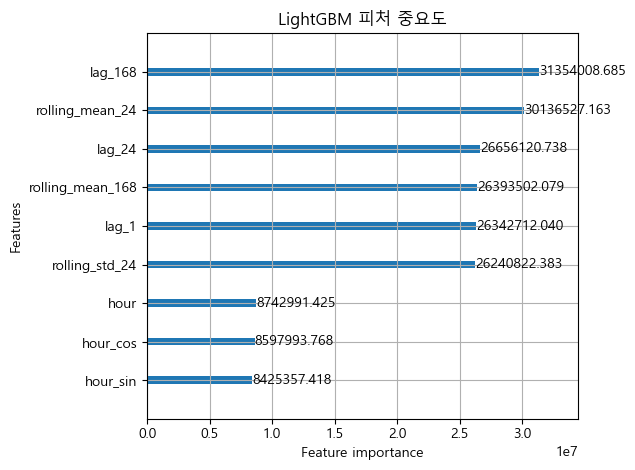

ValueError: x and y must have same first dimension, but have shapes (0,) and (697,)

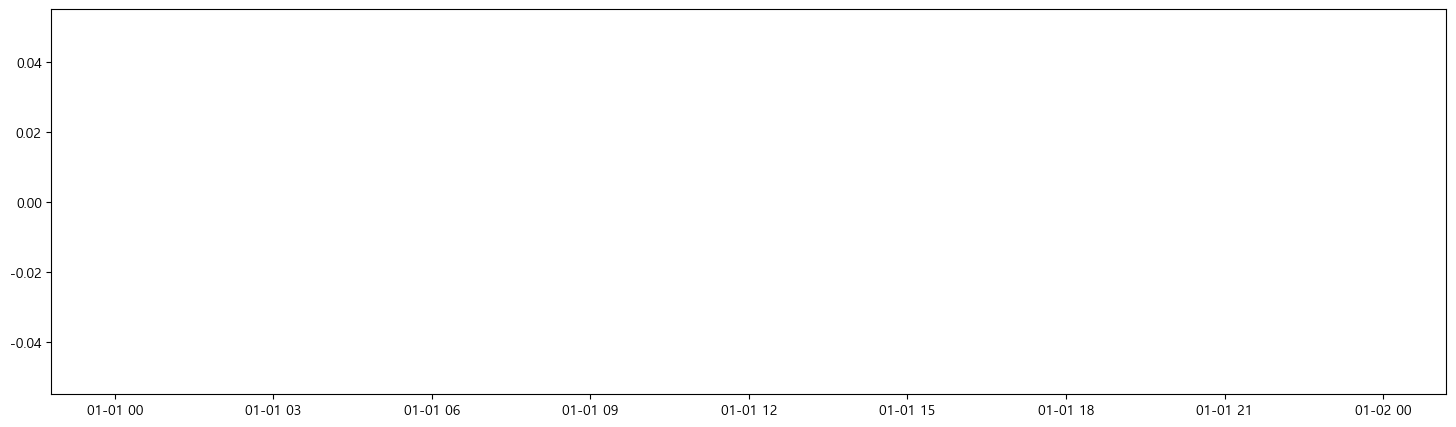

In [30]:
# 피처 중요도
plt.figure(figsize=(10, 5))
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title('LightGBM 피처 중요도')
plt.tight_layout()
plt.savefig('model_01_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# 4월 예측 시각화
plt.figure(figsize=(18, 5))
plt.plot(valid['dt'], y_valid.values, label='실제값', color='steelblue', linewidth=0.8)
plt.plot(valid['dt'], y_pred_valid, label='예측값', color='tomato', linewidth=0.8, alpha=0.8)
plt.title('LightGBM 4월 검증 결과')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('model_02_valid_pred.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# 방법 1 — early_stopping 제거하고 n_estimators 고정
# 방법 2 — 하이퍼파라미터 조정 (num_leaves 늘리기)

model = lgb.LGBMRegressor(
    n_estimators=500,      # early stopping 없이 고정
    learning_rate=0.01,    # 더 천천히 학습
    num_leaves=63,         # 더 복잡한 모델
    min_child_samples=10,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)  # eval_set, callbacks 제거

y_pred_valid = model.predict(X_valid)
mae   = mean_absolute_error(y_valid, y_pred_valid)
smape = np.mean(2 * np.abs(y_pred_valid - y_valid) / (np.abs(y_pred_valid) + np.abs(y_valid))) * 100
print(f'MAE:   {mae:.2f}')
print(f'SMAPE: {smape:.4f}%')

ValueError: Input data must be 2 dimensional and non empty.

In [ ]:
# 오히려 결과 더 나빠짐 > 이 데이터는 모델이 복잡해져도 성능이 안 올라감. 근본적으로 예측할 패턴이 없는 데이터
# EDA에서 확인한 것들
# - 시간 패턴 없음
# - 요일 패턴 없음  
# - 자기상관 없음
#     → 결국 예측 가능한 신호가 없음

# 전략 변경
# 예측 정확도 높이기 → 한계 있음
# 정성평가 40% 채우기 → 여기서 차별화

## 5. 5월 재귀 예측
> 1시간씩 순서대로 예측 → 예측값을 lag에 반영 → 다음 시간 예측

In [32]:
# 5월 예측 시간대 생성 (672시간)
may_dates = pd.date_range('2025-05-01', periods=672, freq='1H')

# 과거 실제값 히스토리 (lag 계산용)
history = hourly[['dt', 'hourly_pow']].copy()

may_preds = []

for dt in may_dates:
    hour = dt.hour
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    # lag 값 계산
    def get_val(h):
        row = history[history['dt'] == dt - pd.Timedelta(hours=h)]
        return row['hourly_pow'].values[0] if len(row) > 0 else np.nan

    lag_1   = get_val(1)
    lag_24  = get_val(24)
    lag_168 = get_val(168)

    # rolling 계산
    recent_24  = history.tail(24)['hourly_pow']
    recent_168 = history.tail(168)['hourly_pow']
    rolling_mean_24  = recent_24.mean()
    rolling_std_24   = recent_24.std()
    rolling_mean_168 = recent_168.mean()

    X_pred = pd.DataFrame([[
        hour, hour_sin, hour_cos,
        lag_1, lag_24, lag_168,
        rolling_mean_24, rolling_std_24, rolling_mean_168
    ]], columns=features)

    pred = model.predict(X_pred)[0]
    may_preds.append(pred)

    # 예측값을 히스토리에 추가 (다음 예측의 lag로 사용)
    new_row = pd.DataFrame({'dt': [dt], 'hourly_pow': [pred]})
    history = pd.concat([history, new_row], ignore_index=True)

print(f'5월 예측 완료: {len(may_preds)}시간')
print(f'예측값 범위: {min(may_preds):.2f} ~ {max(may_preds):.2f}')

5월 예측 완료: 672시간
예측값 범위: 39078.39 ~ 39194.30


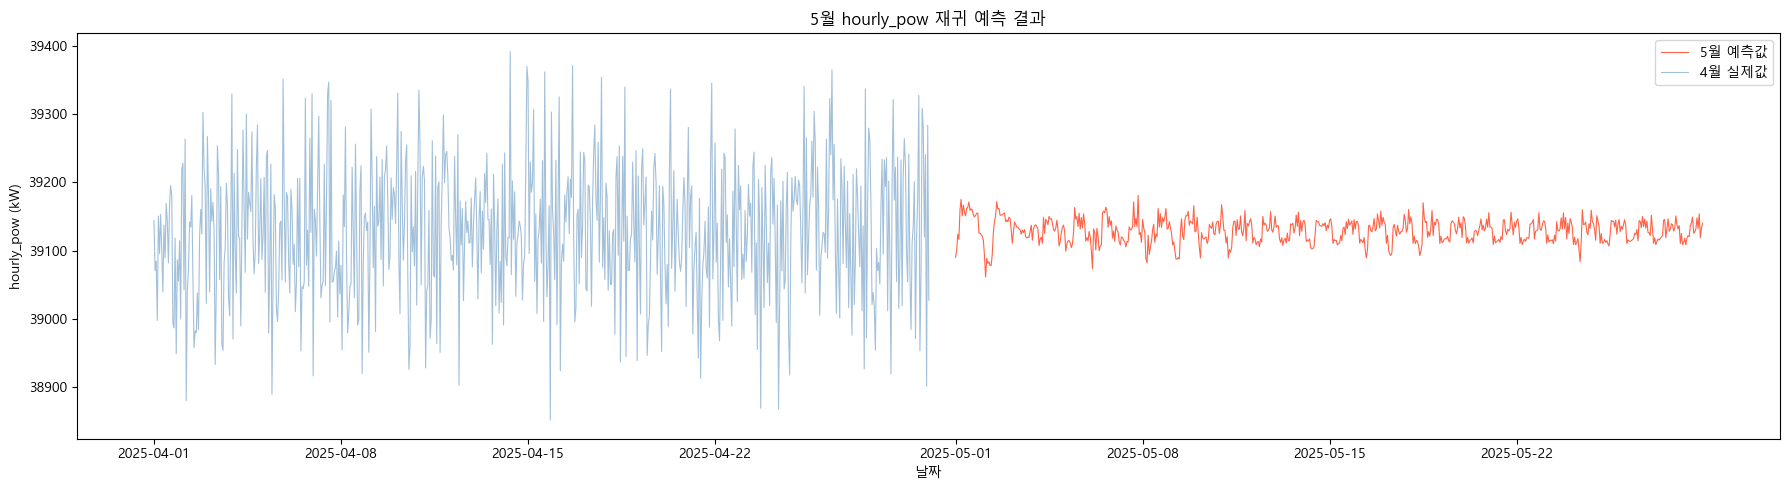

agg_pow:    26,294,782.05 kWh
may_bill:   4,733,060,769 원
may_carbon: 11,148,987.59 kgCO₂

submission.csv 저장 완료!
                    id    hourly_pow       agg_pow      may_bill    may_carbon
0  2025-05-01 00:00:00  39090.340460  2.629478e+07  4.733061e+09  1.114899e+07
1  2025-05-01 01:00:00  39100.363932  2.629478e+07  4.733061e+09  1.114899e+07
2  2025-05-01 02:00:00  39123.941858  2.629478e+07  4.733061e+09  1.114899e+07
3  2025-05-01 03:00:00  39116.605535  2.629478e+07  4.733061e+09  1.114899e+07
4  2025-05-01 04:00:00  39159.661575  2.629478e+07  4.733061e+09  1.114899e+07


In [ ]:
# 5월 예측 시각화
plt.figure(figsize=(18, 5))
plt.plot(may_dates, may_preds, color='tomato', linewidth=0.8, label='5월 예측값')
# 참고용으로 4월 실제값도 같이
plt.plot(valid['dt'], y_valid.values, color='steelblue', linewidth=0.8, alpha=0.5, label='4월 실제값')
plt.title('5월 hourly_pow 재귀 예측 결과')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# 제출 파일 생성
agg_pow    = sum(may_preds)
may_bill   = agg_pow * 180
may_carbon = agg_pow * 0.424

print(f'agg_pow:    {agg_pow:,.2f} kWh')
print(f'may_bill:   {may_bill:,.0f} 원')
print(f'may_carbon: {may_carbon:,.2f} kgCO₂')

submission = pd.DataFrame({
    'id':         may_dates.strftime('%Y-%m-%d %H:%M:%S'),
    'hourly_pow': may_preds,
    'agg_pow':    agg_pow,
    'may_bill':   may_bill,
    'may_carbon': may_carbon
})

submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv 저장 완료!')
print(submission.head())

In [ ]:
# 5월 예측 시각화
plt.figure(figsize=(18, 5))
plt.plot(may_dates, may_preds, color='tomato', linewidth=0.8, label='5월 예측값')
plt.title('5월 hourly_pow 재귀 예측 결과')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('model_03_may_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 이상탐지 — Rolling Z-score

이상 탐지: 23건 / 전체 2736시간


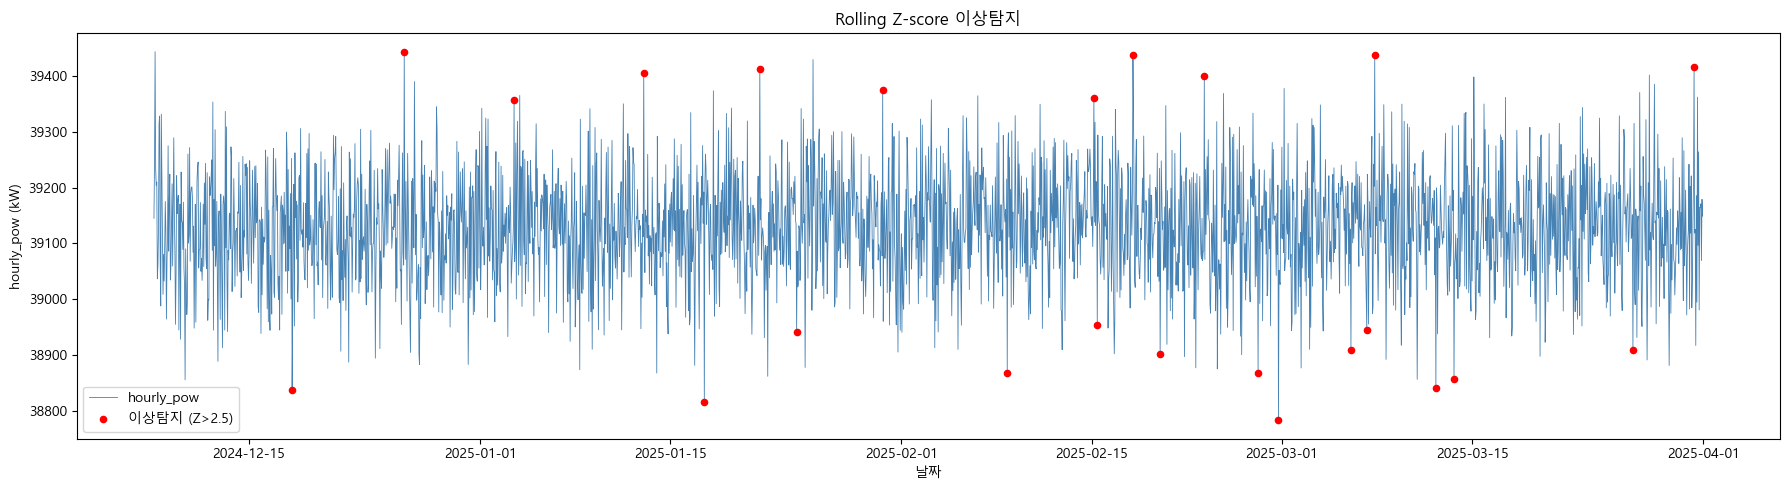

In [ ]:
hourly['rolling_mean'] = hourly['hourly_pow'].rolling(window=24, min_periods=1).mean()
hourly['rolling_std2'] = hourly['hourly_pow'].rolling(window=24, min_periods=1).std()
hourly['z_score'] = (
    (hourly['hourly_pow'] - hourly['rolling_mean']) / hourly['rolling_std2']
)

threshold = 2.5
hourly['is_anomaly'] = hourly['z_score'].abs() > threshold
anomalies = hourly[hourly['is_anomaly']]

print(f'이상 탐지: {len(anomalies)}건 / 전체 {len(hourly)}시간')

plt.figure(figsize=(18, 5))
plt.plot(hourly['dt'], hourly['hourly_pow'],
         color='steelblue', linewidth=0.6, label='hourly_pow')
plt.scatter(anomalies['dt'], anomalies['hourly_pow'],
            color='red', s=20, zorder=5, label=f'이상탐지 (Z>{threshold})')
plt.title('Rolling Z-score 이상탐지')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('model_04_anomaly_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 이상탐지 — Isolation Forest

Isolation Forest 이상 탐지: 28건


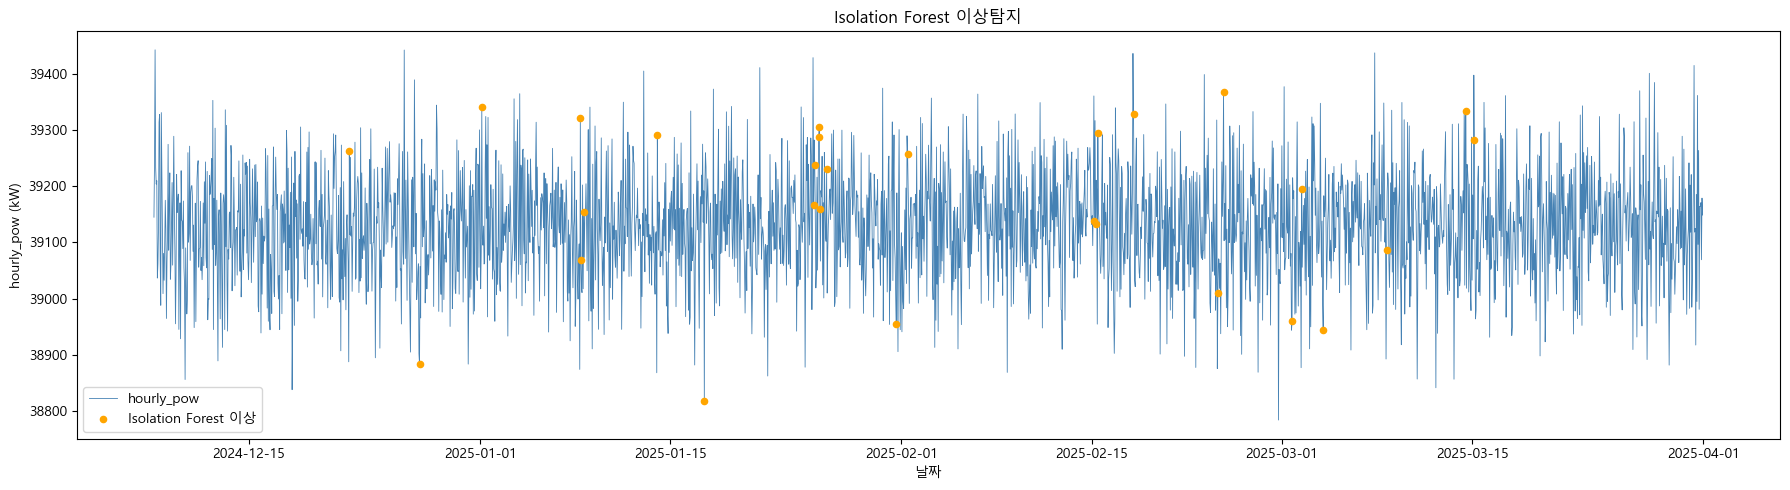

In [ ]:
from sklearn.ensemble import IsolationForest

X_iso = hourly[['hourly_pow', 'lag_1', 'lag_24', 'rolling_mean_24']].dropna()

iso_model = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)
hourly.loc[X_iso.index, 'iso_pred'] = iso_model.fit_predict(X_iso)

iso_anomalies = hourly[hourly['iso_pred'] == -1]
print(f'Isolation Forest 이상 탐지: {len(iso_anomalies)}건')

plt.figure(figsize=(18, 5))
plt.plot(hourly['dt'], hourly['hourly_pow'],
         color='steelblue', linewidth=0.6, label='hourly_pow')
plt.scatter(iso_anomalies['dt'], iso_anomalies['hourly_pow'],
            color='orange', s=20, zorder=5, label='Isolation Forest 이상')
plt.title('Isolation Forest 이상탐지')
plt.xlabel('날짜')
plt.ylabel('hourly_pow (kW)')
plt.legend()
plt.tight_layout()
plt.savefig('model_05_anomaly_iforest.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 제출 파일 생성

In [ ]:
# agg_pow = 5월 전체 누적 합계
agg_pow    = sum(may_preds)
may_bill   = agg_pow * 180
may_carbon = agg_pow * 0.424

print(f'agg_pow:    {agg_pow:,.2f} kWh')
print(f'may_bill:   {may_bill:,.0f} 원')
print(f'may_carbon: {may_carbon:,.2f} kgCO₂')

submission = pd.DataFrame({
    'id':         may_dates.strftime('%Y-%m-%d %H:%M:%S'),
    'hourly_pow': may_preds,
    'agg_pow':    agg_pow,    # 전 행 동일값
    'may_bill':   may_bill,
    'may_carbon': may_carbon
})

submission.to_csv('submission.csv', index=False)
print('\nsubmission.csv 저장 완료!')
print(submission.head(10))

agg_pow:    26,294,782.05 kWh
may_bill:   4,733,060,769 원
may_carbon: 11,148,987.59 kgCO₂

submission.csv 저장 완료!
                    id    hourly_pow       agg_pow      may_bill    may_carbon
0  2025-05-01 00:00:00  39090.340460  2.629478e+07  4.733061e+09  1.114899e+07
1  2025-05-01 01:00:00  39100.363932  2.629478e+07  4.733061e+09  1.114899e+07
2  2025-05-01 02:00:00  39123.941858  2.629478e+07  4.733061e+09  1.114899e+07
3  2025-05-01 03:00:00  39116.605535  2.629478e+07  4.733061e+09  1.114899e+07
4  2025-05-01 04:00:00  39159.661575  2.629478e+07  4.733061e+09  1.114899e+07
5  2025-05-01 05:00:00  39175.049604  2.629478e+07  4.733061e+09  1.114899e+07
6  2025-05-01 06:00:00  39150.944162  2.629478e+07  4.733061e+09  1.114899e+07
7  2025-05-01 07:00:00  39166.800229  2.629478e+07  4.733061e+09  1.114899e+07
8  2025-05-01 08:00:00  39156.543722  2.629478e+07  4.733061e+09  1.114899e+07
9  2025-05-01 09:00:00  39150.975677  2.629478e+07  4.733061e+09  1.114899e+07


In [ ]:
sample = pd.read_csv('submissionfile_sample.csv')
print(sample.shape)
print(sample)
print(sample.dtypes)

(24, 5)
                        id  hourly_pow         agg_pow        may_bill  \
0      2025-05-01 00:00:00         0.0  동일한 5월의 전체 누적량  동일한 5월 전체 전기요금   
1      2025-05-01 01:00:00         0.0  동일한 5월의 전체 누적량  동일한 5월 전체 전기요금   
2      2025-05-01 02:00:00         0.0  동일한 5월의 전체 누적량  동일한 5월 전체 전기요금   
3      2025-05-01 03:00:00         0.0             NaN               .   
4      2025-05-01 04:00:00         0.0             NaN               .   
5      2025-05-01 05:00:00         0.0             NaN             NaN   
6      2025-05-01 06:00:00         0.0             NaN             NaN   
7      2025-05-01 07:00:00         0.0             NaN             NaN   
8      2025-05-01 08:00:00         0.0             NaN             NaN   
9      2025-05-01 09:00:00         0.0             NaN             NaN   
10     2025-05-01 10:00:00         0.0             NaN             NaN   
11     2025-05-01 11:00:00         0.0             NaN             NaN   
12     2025-05-01 12:00:00    